# Descargar CSV material

In [18]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("neurocipher/heartdisease")
os.mkdir("CSV")
destino = "CSV"
os.makedirs(destino, exist_ok=True)

for archivo in os.listdir(path):
    if archivo.endswith(".csv"):
        shutil.copy(
            os.path.join(path, archivo),
            os.path.join(destino, archivo)
        )

print("CSV copiados a:", os.path.abspath(destino))


CSV copiados a: c:\Users\Danie\Documents\TDSE\trabajo 2\CSV


## Paso 1:

In [19]:
import pandas as pd

data = pd.read_csv(os.path.join(destino, "Heart_Disease_Prediction.csv"))
print(data.head())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2                        0   

# Binarizado 

In [20]:
data["Heart Disease"] = data["Heart Disease"].replace({
    "Absence": 0,
    "Presence": 1
})
print(data.head())


   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3             1  
1                        0         7             0  
2                        0   

### The dataset contains clinical records of patients used to predict the presence of heart disease.

# EDA


In [22]:
data.shape


(270, 14)

In [23]:
data.columns


Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), object(1)
m

In [25]:
data["Heart Disease"].value_counts()


Heart Disease
0    150
1    120
Name: count, dtype: int64

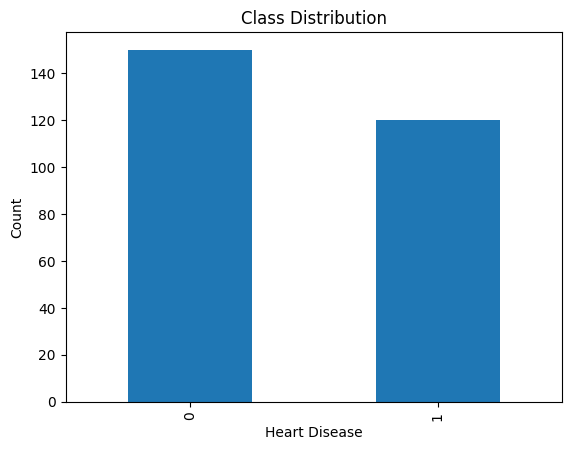

In [26]:
import matplotlib.pyplot as plt

data["Heart Disease"].value_counts().plot(kind="bar")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()


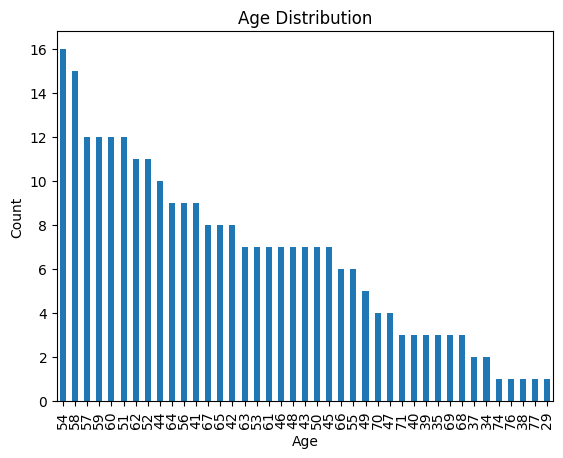

In [27]:
import matplotlib.pyplot as plt

data["Age"].value_counts().plot(kind="bar")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


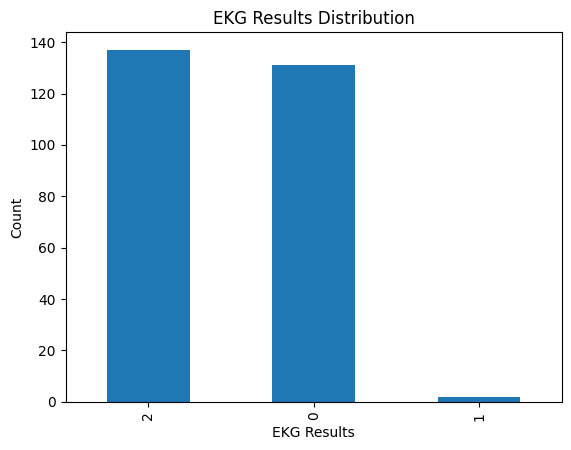

In [29]:
import matplotlib.pyplot as plt

data["EKG results"].value_counts().plot(kind="bar")
plt.xlabel("EKG Results")
plt.ylabel("Count")
plt.title("EKG Results Distribution")
plt.show()

### There are no null data in this database

In [31]:
data.isnull().sum()


Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [32]:
data["Sex"].value_counts()
data["Chest pain type"].value_counts()


Chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64

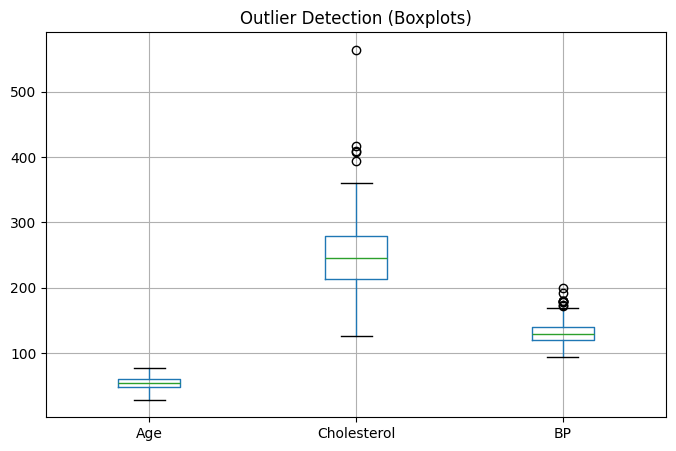

In [35]:
data[["Age", "Cholesterol", "BP"]].boxplot(figsize=(8,5))
plt.title("Outlier Detection (Boxplots)")
plt.show()


# Corelacion

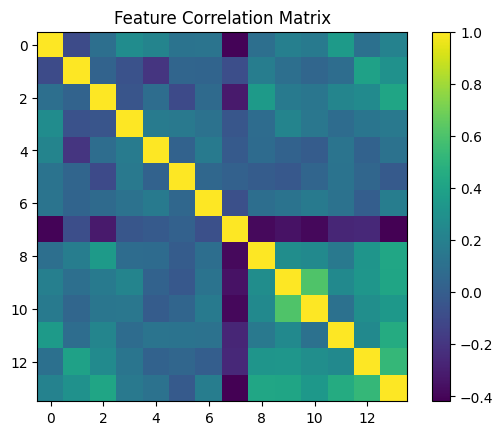

In [36]:
import numpy as np

corr = data.corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.show()


# PREP

In [40]:
# Target
y = data["Heart Disease"].values  

# Features
features = [
    "Age",
    "Cholesterol",
    "BP",
    "Max HR",
    "ST depression",
    "Number of vessels fluro"
]

X = data[features].values  
print("X shape:", X.size, ", y shape:", y.size)


X shape: 1620 , y shape: 270


In [41]:
import numpy as np

np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

split_0 = int(0.7 * len(idx_0))
split_1 = int(0.7 * len(idx_1))

train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
test_idx  = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(X_train.shape, X_test.shape)


(189, 6) (81, 6)
